# 02 — Análisis Exploratorio
## Pipeline CAD-TBX11K | Diagnóstico Asistido por Computador en Tuberculosis

Este notebook explora visualmente el dataset para entender qué información contienen
las radiografías **antes de cualquier preprocesamiento**. Se trabaja intencionalmente
sobre imágenes crudas para separar el efecto de los datos del efecto del pipeline.

### Preguntas que se responden

1. ¿Las radiografías de distintas clases presentan diferencias visibles a simple vista?
2. ¿Existen diferencias en la distribución de intensidad entre clases?
3. ¿Qué métricas básicas de intensidad tienen mayor capacidad discriminativa?

### Métricas de intensidad analizadas

| Métrica     | Descripción                                                        |
|-------------|--------------------------------------------------------------------|
| `mean`      | Brillo promedio global de la imagen                                |
| `std`       | Variabilidad de brillo — tejidos heterogéneos producen mayor std   |
| `contrast`  | Diferencia entre el píxel más brillante y el más oscuro            |
| `entropy`   | Desorden del histograma — lesiones TB aumentan la entropía         |


## 0. Configuración del entorno

In [1]:
# Se configura el path del proyecto y se importan las funciones del framework.

import sys, os, warnings
warnings.filterwarnings('ignore')
import pandas as pd
from pathlib import Path
import numpy as np

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)


from src.data import (
    download_dataset, get_data_root, build_base_dataframe,
    LABEL_MAP, PALETTE,
)
from src.visualization import (
    set_publication_style,
    plot_sample_images,
    plot_intensity_histograms,
    compute_intensity_stats,
    plot_intensity_metrics,
)

set_publication_style()
print('Entorno configurado correctamente.')

Entorno configurado correctamente.


## 1. Carga del DataFrame base

In [2]:
# Se carga el DataFrame base desde data/df_base.csv.
# Si aún no existe, ejecutar primero el notebook 01 para generarlo.

CSV_PATH = Path('..') / 'data' / 'df_base.csv'

if CSV_PATH.exists():
    df_base = pd.read_csv(CSV_PATH)
    print(f'DataFrame cargado desde: {CSV_PATH.resolve()}')
    print(f'Total imágenes: {len(df_base)}')
else:
    print(f'[ERROR] No se encontró: {CSV_PATH.resolve()}')
    print('Ejecuta primero el notebook 01 para generar df_base.csv')

print()
print(df_base['class_name'].value_counts())

DataFrame cargado desde: C:\Users\bernarda.salazar\Documents\GitHub\CAD_TBX11K\data\df_base.csv
Total imágenes: 30

class_name
health    10
sick      10
tb        10
Name: count, dtype: int64


## 2. Visualización de ejemplos por clase

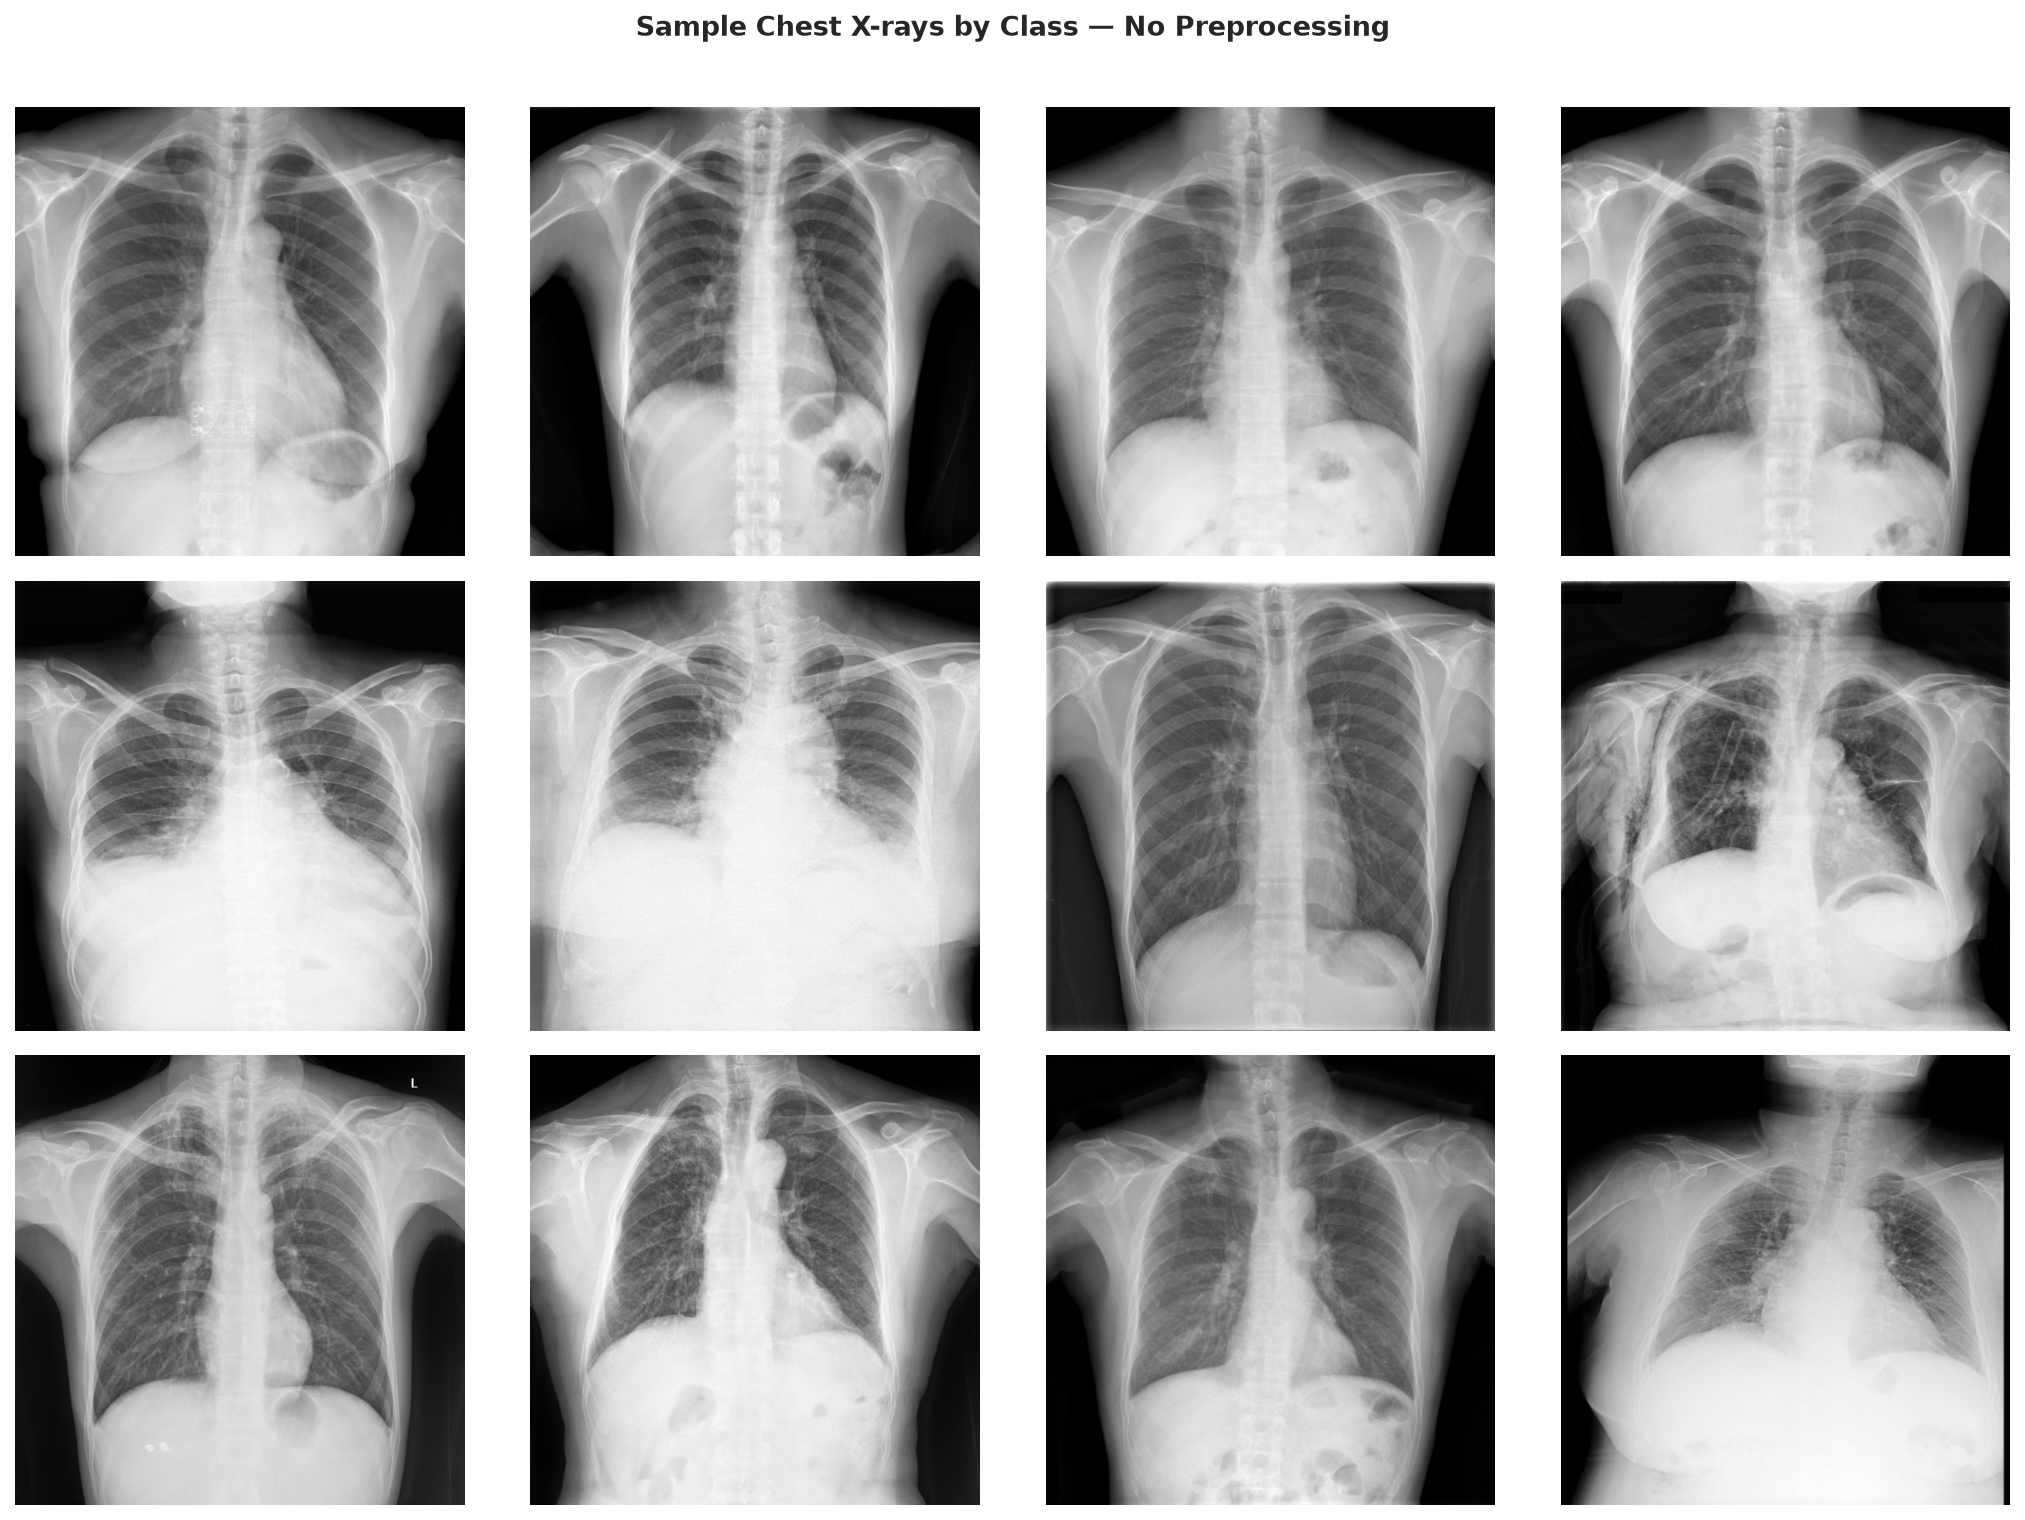

In [3]:
# Se muestran 4 radiografías por clase sin ningún preprocesamiento.
# El objetivo es calibrar la percepción visual antes de cuantificar las diferencias.
# Las imágenes se cargan en escala de grises con OpenCV.
# Referencia cv2.imread: https://docs.opencv.org/4.x/d4/da8/group__imgcodecs.html

plot_sample_images(df_base, n=4, random_state=42)

## 3. Histogramas de intensidad por clase — imágenes sin preprocesar

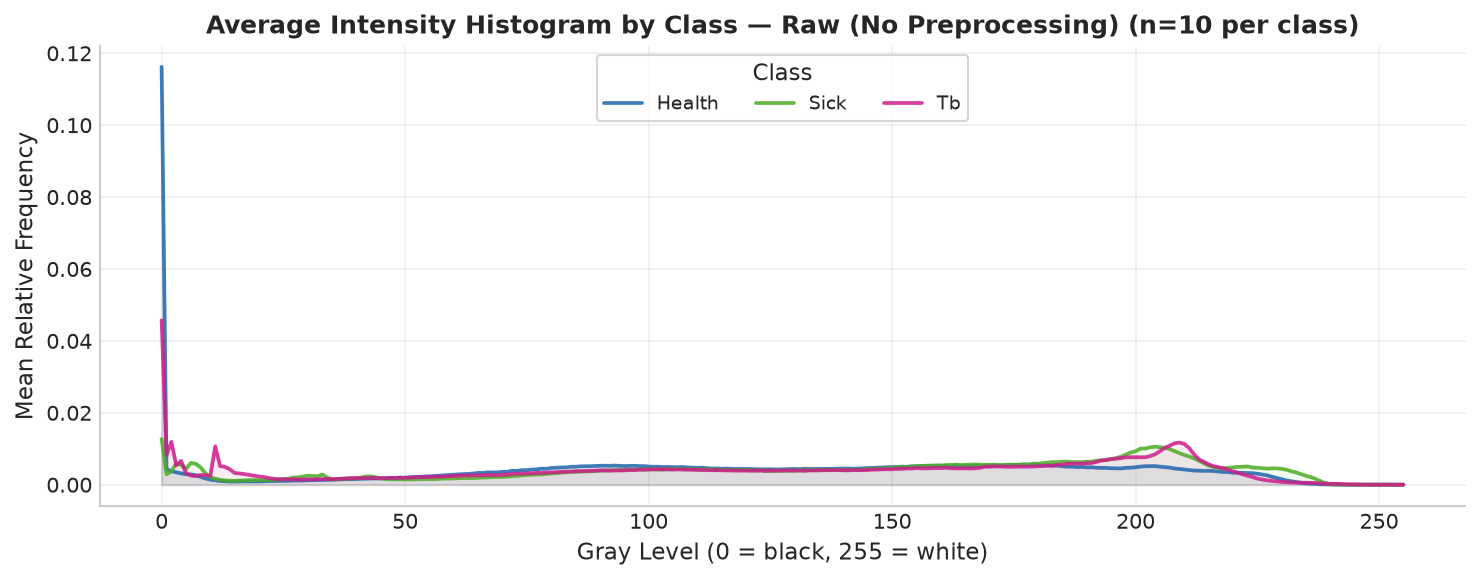

In [6]:
# Se calcula el histograma de intensidad promedio por clase.
# n_hist se ajusta automáticamente si el modo prueba tiene menos imágenes disponibles.
# Un histograma promedio reduce el efecto de variaciones individuales y muestra
# la tendencia central de la distribución de brillo por clase.
# Si las curvas difieren entre clases, la intensidad contiene información discriminativa.

N_HIST = min(80, len(df_base[df_base['class_name'] == 'health']))

plot_intensity_histograms(df_base, n_hist=N_HIST, preprocessed=False, random_state=42)

## 4. Métricas de intensidad por clase — cálculo tabular

In [7]:
# Se calculan las cuatro métricas sobre n imágenes por clase.
# La tabla de promedios permite comparar cuantitativamente las diferencias entre clases
# antes de visualizarlas mediante los gráficos de distribución.

N_HIST = min(80, len(df_base[df_base['class_name'] == 'health']))

stats_df = compute_intensity_stats(df_base, n_hist=N_HIST, random_state=42)

print(f'Promedios por clase (imágenes sin preprocesar, n={N_HIST} por clase):')
print(stats_df.groupby('class_name')[['mean','std','contrast','entropy']].mean().round(3).to_string())

Promedios por clase (imágenes sin preprocesar, n=10 por clase):
               mean     std  contrast  entropy
class_name                                    
health      116.454  65.702     237.1    4.989
sick        141.613  61.611     234.1    5.106
tb          126.957  69.014     236.4    5.099


## 5. Distribución de métricas por clase

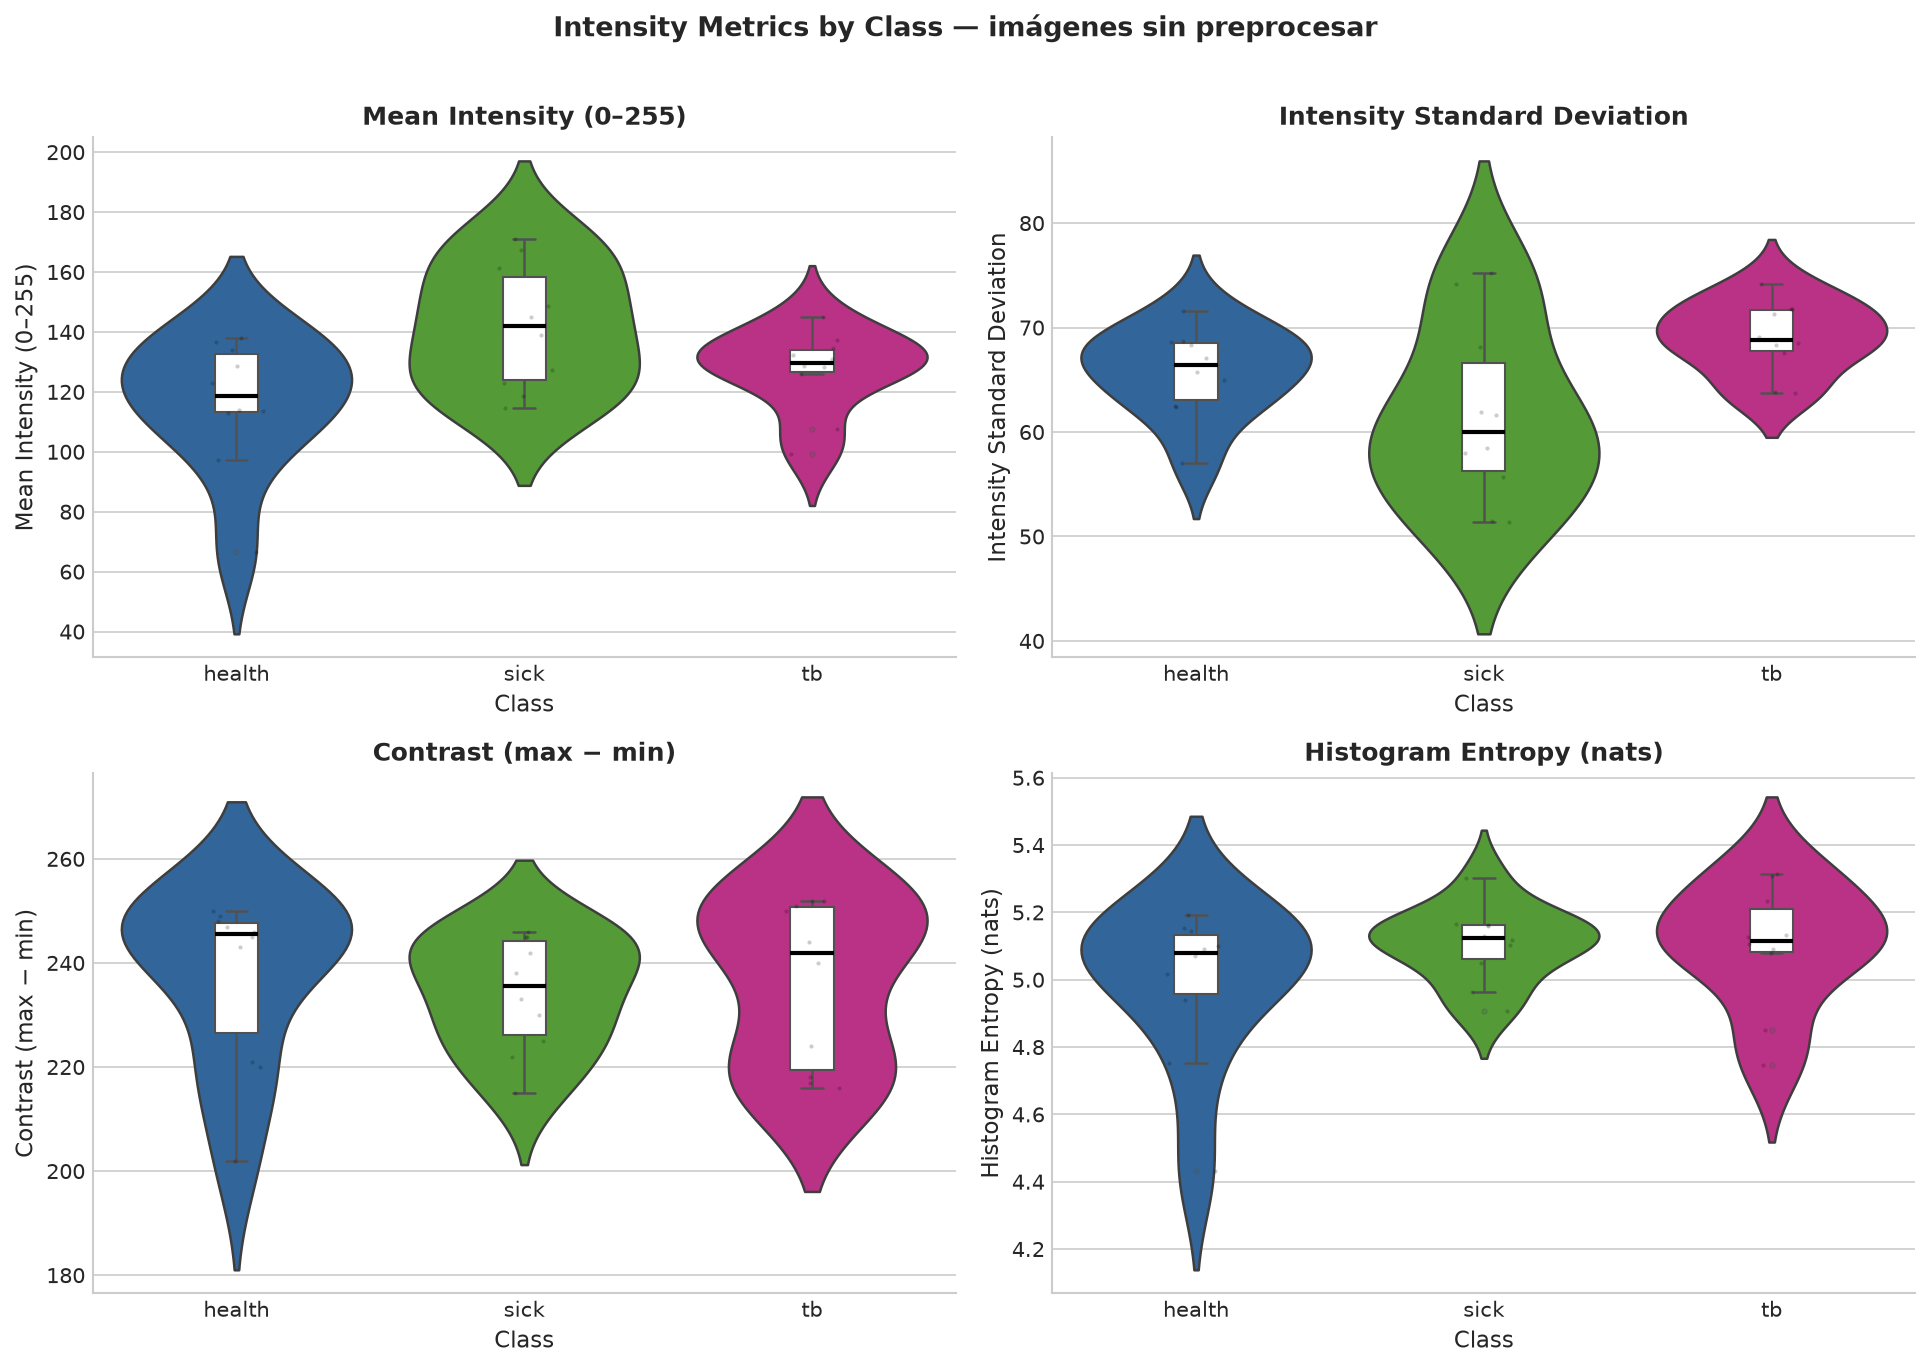

In [10]:
# Se visualizan las distribuciones mediante violin plots superpuestos con
# box plots y strip plots. Esta combinación muestra simultáneamente:
#   - la forma de la distribución (violín)
#   - mediana, cuartiles y valores atípicos (caja)
#   - las observaciones individuales (puntos)

plot_intensity_metrics(stats_df, title_suffix='imágenes sin preprocesar')

## 6. Tabla resumen de métricas

In [14]:
# Se consolida una tabla comparativa de métricas por clase con media y desviación
# estándar. Esta tabla sirve como línea base (before) para comparar con los
# resultados post-preprocesamiento en el notebook 03.

resumen = stats_df.groupby('class_name')[['mean', 'std', 'contrast', 'entropy']] \
                  .agg(['mean', 'std'])

resumen.columns = ['_'.join(col) for col in resumen.columns]
resumen = resumen.round(3)

print('Tabla resumen de métricas de intensidad (imágenes crudas):')
print(resumen)

Tabla resumen de métricas de intensidad (imágenes crudas):
            mean_mean  mean_std  std_mean  std_std  contrast_mean  \
class_name                                                          
health        116.454    21.709    65.702    4.203          237.1   
sick          141.613    20.554    61.611    8.504          234.1   
tb            126.957    13.645    69.014    3.398          236.4   

            contrast_std  entropy_mean  entropy_std  
class_name                                           
health            16.616         4.989        0.233  
sick              10.898         5.106        0.112  
tb                15.778         5.099        0.181  


## Conclusiones preliminares

La Tabla anterior resume las estadísticas descriptivas obtenidas a partir de una muestra de diez imágenes por clase antes de aplicar cualquier etapa de preprocesamiento. Aunque el tamaño de la muestra es reducido, los resultados permiten identificar algunas diferencias iniciales entre las categorías analizadas.

La intensidad media es la métrica que presenta la mayor separación entre clases. Las imágenes de la clase sick registran el valor promedio más alto (141.6 ± 20.6), seguidas por tb (127.0 ± 13.6) y health (116.5 ± 21.7). Esto sugiere que las imágenes etiquetadas como sick tienden a ser globalmente más brillantes, mientras que las imágenes health presentan niveles medios de intensidad inferiores.

En contraste, la desviación estándar de intensidad, que refleja la variabilidad interna de los niveles de gris, muestra un comportamiento diferente. La clase tb alcanza el promedio más elevado (69.0 ± 3.4), seguida por health (65.7 ± 4.2), mientras que sick presenta el valor más bajo (61.6 ± 8.5). Estos resultados indican que las imágenes tb contienen una distribución tonal más dispersa, mientras que las imágenes sick presentan una mayor heterogeneidad entre muestras.

Respecto al contraste, las diferencias entre clases son relativamente pequeñas. Los valores medios oscilan entre 234.1 y 237.1, lo que indica que las tres categorías poseen rangos dinámicos similares. Además, las desviaciones estándar muestran una dispersión moderada, especialmente en health y tb. Este comportamiento sugiere que el contraste, por sí solo, podría tener una capacidad limitada para discriminar entre clases.

La entropía del histograma presenta valores muy próximos entre categorías, con medias cercanas a 5.0 nats. No obstante, las clases sick (5.106) y tb (5.099) muestran valores ligeramente superiores a health (4.989), lo que podría indicar una distribución tonal algo más compleja. Sin embargo, el solapamiento observado entre las distribuciones sugiere que estas diferencias son sutiles.

En conjunto, los resultados indican que la intensidad media y, en menor medida, la desviación estándar de intensidad, son las métricas que muestran una mayor capacidad para diferenciar las clases en esta muestra exploratoria. Por el contrario, contraste y entropía presentan valores muy similares entre categorías, evidenciando un importante grado de solapamiento. Debido al reducido número de imágenes analizadas, estas observaciones deben considerarse preliminares y servir principalmente como referencia para comparar el efecto de las etapas de preprocesamiento que se aplicarán posteriormente sobre el conjunto completo de datos.




**Siguiente etapa:** `03_Preprocesamiento.ipynb`